In [1]:
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time
from physical_diffusion_fns.network_fns import setup_duffing_network_with_external_force_energy_fn, setup_overdamped_SDE, solve_SDE  

jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


# Setup Problem

### Generate samples from a Gaussian mixture - the target distribution

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.3, .7])

# Define means
means = jnp.array([
    [1., .7],   # mean of first Gaussian
    [-1., -7.],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])
# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal of target distributions

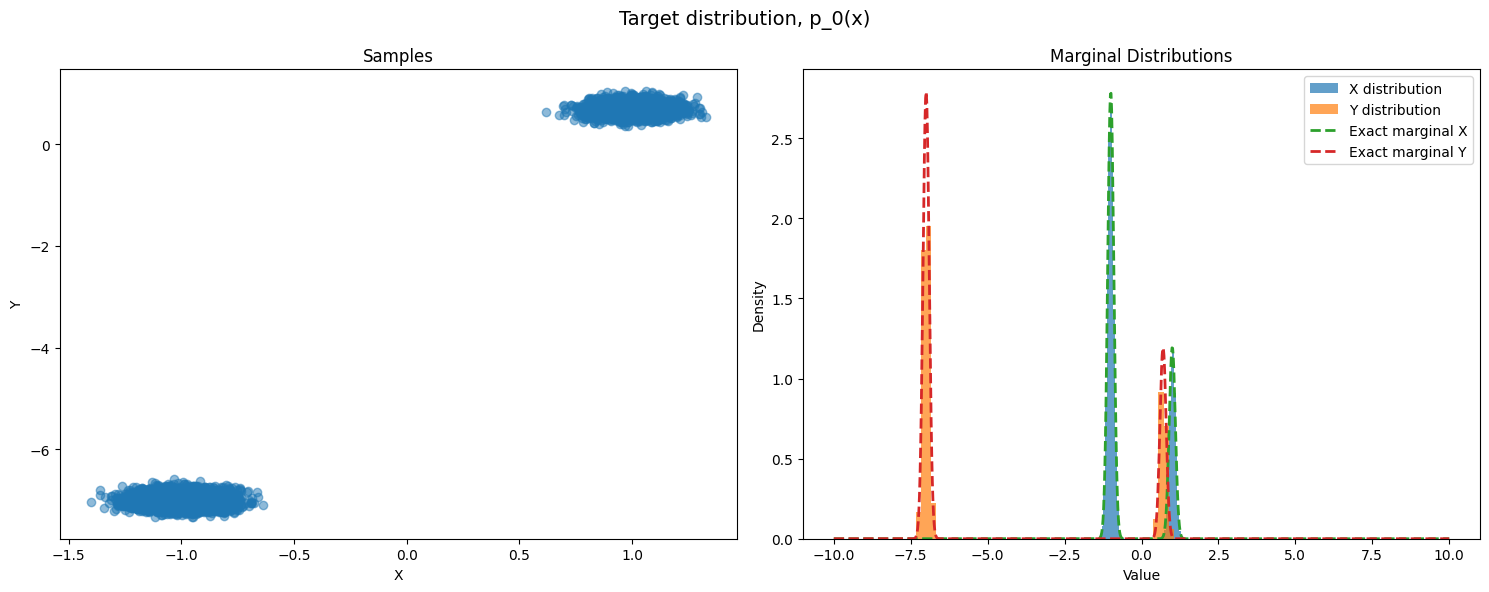

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-10, 10, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Network size and topology

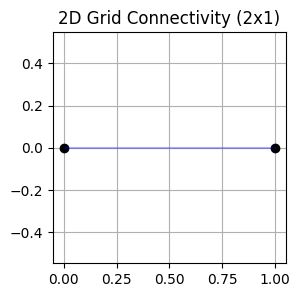

In [4]:
N_osc = 2
connectivity = jnp.array([[0, 1]])
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

### Setup initial params 

In [5]:
k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 0.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
bias_0 = jnp.array([5.,0.,])
params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, bias_0)
params_names = ["k_lin", "k_duff", "c_lin", "c_optomech", "external_force"]
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)

### Build energy

In [6]:
energy_fn = setup_duffing_network_with_external_force_energy_fn(connectivity, unflatten)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


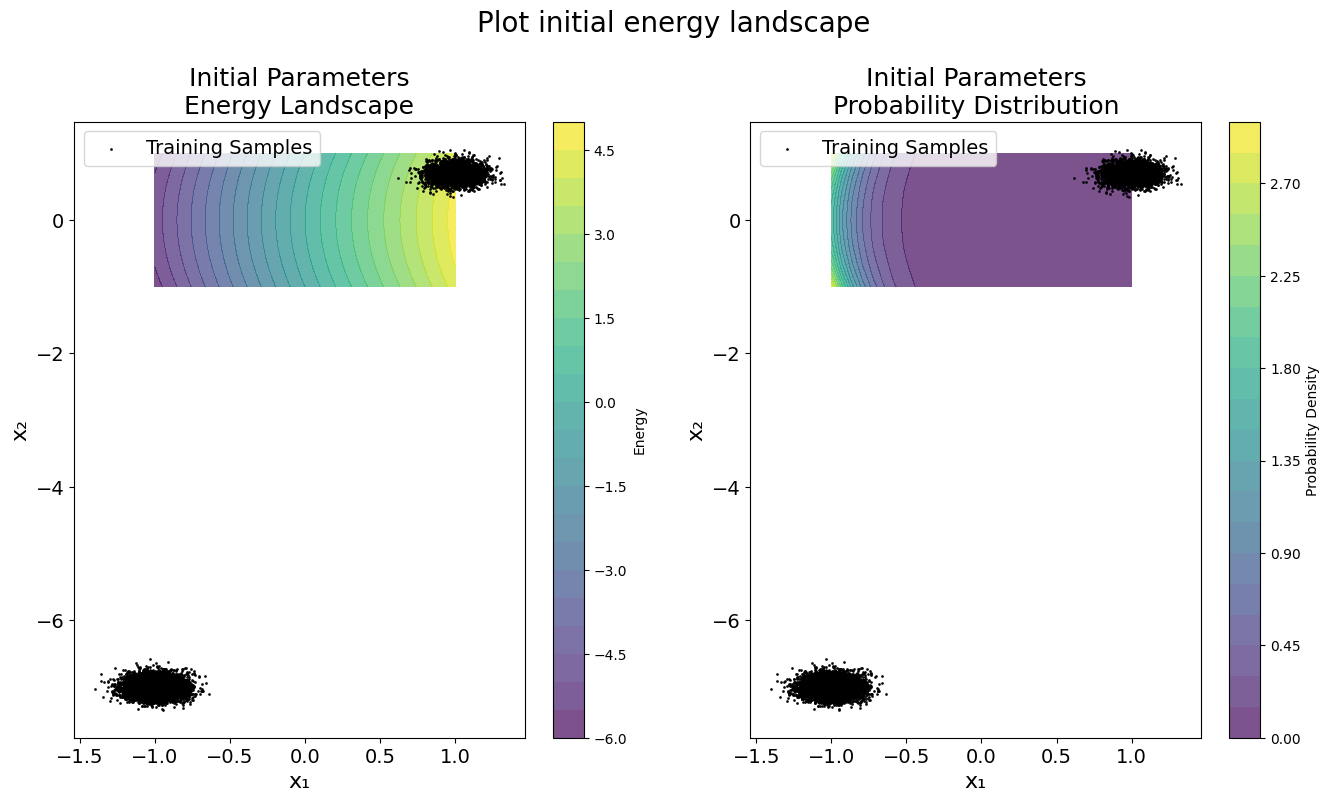

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [8]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 50
t_forward = 1.0
sigma_forward = .5
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-9), jnp.log(t_forward), n_time_steps))
forward_time_pts = forward_time_pts.at[0].set(0.)

# Optimization parameters
learning_rate = .01
n_epochs = 100000//2
batch_size = 2*128
window_size=1000
tolerance=1e-16
patience=50


In [10]:
comment = "with_external_force"
optimization_folder = (f"{training_method}_"
           f"t_forward_{t_forward}_"
           f"n_timesteps_{n_time_steps}_"
           f"lr_{learning_rate}_"
           f"epochs_{n_epochs}_"
           f"batch_{batch_size}_"
           f"window_{window_size}_"
           f"tol_{tolerance}_"
           f"patience_{patience}_"
           f"{comment}")

In [11]:
# Setup output directories
base_dir = "out/problems"
problem_type_folder = "mixture_gaussians_sampling"
problem_folder = f"weights_{weights}_means_{means.flatten()}_covs_{covs.flatten()}"  # Replace with your actual parameters

output_dir = os.path.join(base_dir, problem_type_folder, problem_folder,optimization_folder)

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)

### Print final distribution of the forward

Saving figure to out/problems/mixture_gaussians_sampling/weights_[0.3 0.7]_means_[ 1.   0.7 -1.  -7. ]_covs_[0.01 0.   0.   0.01 0.01 0.   0.   0.01]/SM_t_forward_1.0_n_timesteps_50_lr_0.01_epochs_50000_batch_256_window_1000_tol_1e-16_patience_50_with_external_force


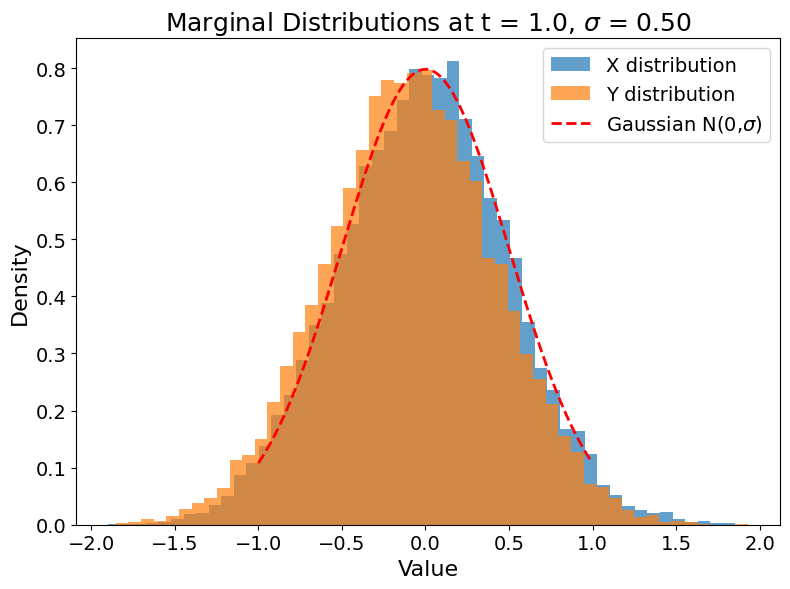

In [12]:
key, subkey = jr.split(key)
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey)
plot_forward_marginals(samples_t, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=True, fontsize=16)

Optimization for time 0.0
Epoch 0 - Loss: 27.8727
Epoch 100 - Loss: -4.8487
Epoch 200 - Loss: -9.1365
Epoch 300 - Loss: -13.1361
Epoch 400 - Loss: -17.3206
Epoch 500 - Loss: -20.1615
Epoch 600 - Loss: -27.2076
Epoch 700 - Loss: -28.8873
Epoch 800 - Loss: -32.4773
Epoch 900 - Loss: -32.1869
Epoch 1000 - Loss: -35.8885
Epoch 1100 - Loss: -39.8182
Epoch 1200 - Loss: -39.3552
Epoch 1300 - Loss: -43.5807
Epoch 1400 - Loss: -46.5787
Epoch 1500 - Loss: -45.0908
Epoch 1600 - Loss: -43.3688
Epoch 1700 - Loss: -45.1909
Epoch 1800 - Loss: -49.0503
Epoch 1900 - Loss: -48.8075
Epoch 2000 - Loss: -54.6259
Epoch 2100 - Loss: -47.4496
Epoch 2200 - Loss: -51.6129
Epoch 2300 - Loss: -56.3175
Epoch 2400 - Loss: -52.7198
Epoch 2500 - Loss: -51.7075
Epoch 2600 - Loss: -47.5235
Epoch 2700 - Loss: -56.1472
Epoch 2800 - Loss: -53.7757
Epoch 2900 - Loss: -58.5060
Epoch 3000 - Loss: -57.6568
Epoch 3100 - Loss: -57.3730
Epoch 3200 - Loss: -62.4704
Epoch 3300 - Loss: -62.1040
Epoch 3400 - Loss: -59.4574
Epoch 350

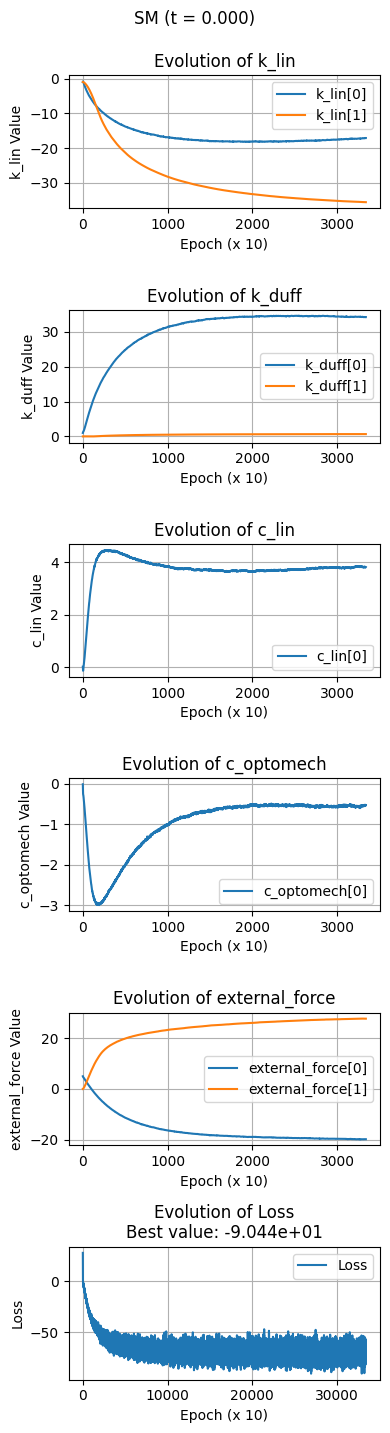

Optimization for time 1.5264179671752362e-09
Epoch 0 - Loss: -72.5198
Epoch 100 - Loss: -73.4839
Epoch 200 - Loss: -79.0371
Epoch 300 - Loss: -75.8617
Epoch 400 - Loss: -64.7947
Epoch 500 - Loss: -70.6413
Epoch 600 - Loss: -61.5039
Epoch 700 - Loss: -71.7722
Epoch 800 - Loss: -71.6475
Epoch 900 - Loss: -84.9460
Epoch 1000 - Loss: -65.4313
Epoch 1100 - Loss: -76.1215
Epoch 1200 - Loss: -73.8039
Epoch 1300 - Loss: -61.1933
Epoch 1400 - Loss: -70.9109
Epoch 1500 - Loss: -64.6678
Epoch 1600 - Loss: -75.5957
Epoch 1700 - Loss: -79.3909
Epoch 1800 - Loss: -64.2120
Epoch 1900 - Loss: -75.5862
Epoch 2000 - Loss: -57.2162
Epoch 2100 - Loss: -67.9920
Epoch 2200 - Loss: -70.8556
Epoch 2300 - Loss: -62.8816
Epoch 2400 - Loss: -71.9043
Epoch 2500 - Loss: -71.8487
Epoch 2600 - Loss: -56.1732
Epoch 2700 - Loss: -83.4642
Epoch 2800 - Loss: -63.7463
Epoch 2900 - Loss: -59.9987
Epoch 3000 - Loss: -65.0087
Epoch 3100 - Loss: -65.6514
Epoch 3200 - Loss: -64.3588
Epoch 3300 - Loss: -77.9359
Epoch 3400 - Lo

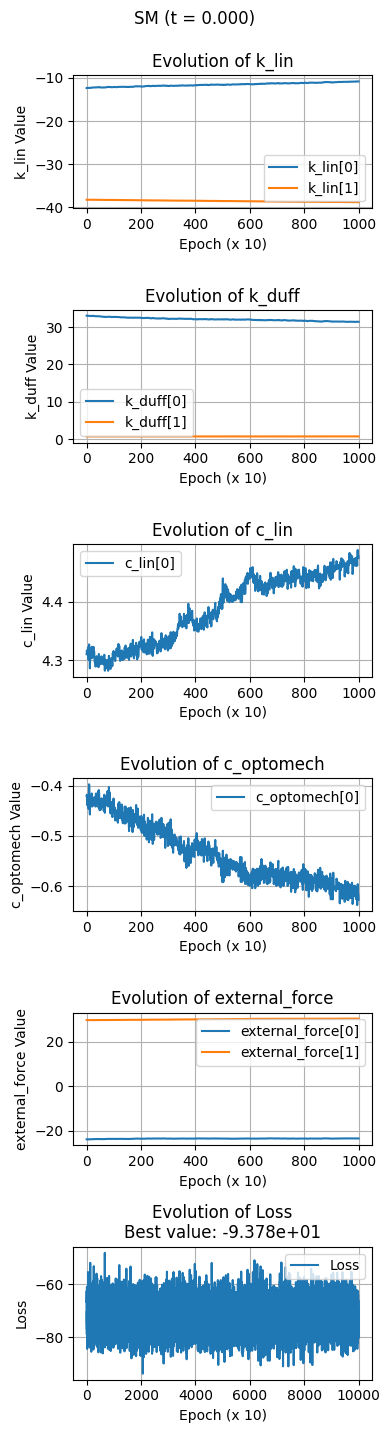

Optimization for time 1.0481131341546869e-07
Epoch 0 - Loss: -68.3884
Epoch 100 - Loss: -76.4436
Epoch 200 - Loss: -80.9346
Epoch 300 - Loss: -66.7649
Epoch 400 - Loss: -79.7022
Epoch 500 - Loss: -79.7023
Epoch 600 - Loss: -60.2932
Epoch 700 - Loss: -72.3471
Epoch 800 - Loss: -80.7897
Epoch 900 - Loss: -74.2910
Epoch 1000 - Loss: -73.4157
Epoch 1100 - Loss: -66.7342
Epoch 1200 - Loss: -62.5692
Epoch 1300 - Loss: -73.4485
Epoch 1400 - Loss: -73.3045
Epoch 1500 - Loss: -73.8597
Epoch 1600 - Loss: -78.3652
Epoch 1700 - Loss: -75.3194
Epoch 1800 - Loss: -70.7995
Epoch 1900 - Loss: -66.3305
Epoch 2000 - Loss: -60.6716
Epoch 2100 - Loss: -76.9494
Epoch 2200 - Loss: -77.5478
Epoch 2300 - Loss: -68.1820
Epoch 2400 - Loss: -67.5840
Epoch 2500 - Loss: -75.1726
Epoch 2600 - Loss: -76.9055
Epoch 2700 - Loss: -73.5843
Epoch 2800 - Loss: -72.8602
Epoch 2900 - Loss: -73.5863
Epoch 3000 - Loss: -74.4685
Epoch 3100 - Loss: -71.2667
Epoch 3200 - Loss: -80.6685
Epoch 3300 - Loss: -75.0697
Epoch 3400 - Lo

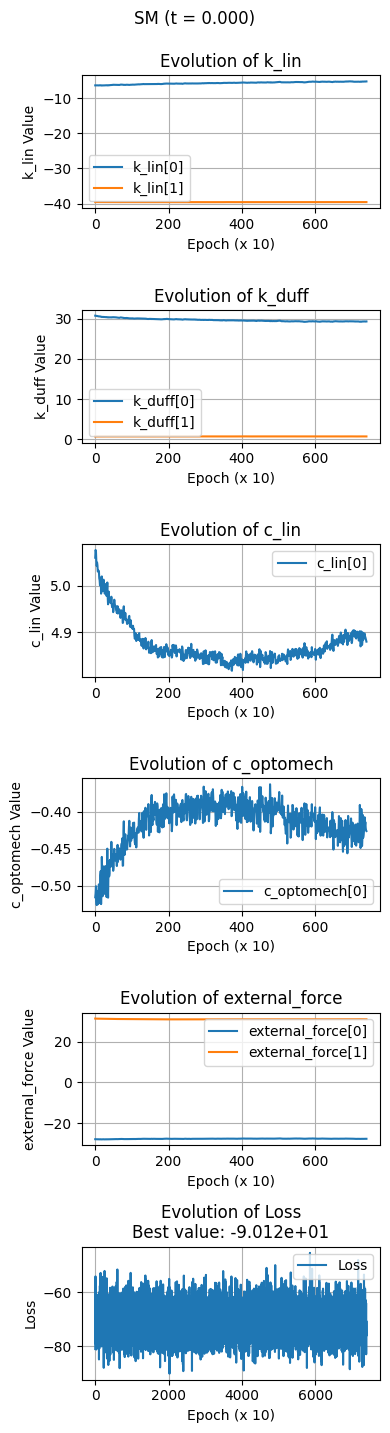

Optimization for time 7.19685673001151e-06
Epoch 0 - Loss: -66.1670
Epoch 100 - Loss: -69.0892
Epoch 200 - Loss: -65.0916
Epoch 300 - Loss: -63.1350
Epoch 400 - Loss: -70.8032
Epoch 500 - Loss: -76.4513
Epoch 600 - Loss: -74.0107
Epoch 700 - Loss: -75.9299
Epoch 800 - Loss: -74.3496
Epoch 900 - Loss: -71.1533
Epoch 1000 - Loss: -79.2950
Epoch 1100 - Loss: -65.6646
Epoch 1200 - Loss: -72.2172
Epoch 1300 - Loss: -74.7848
Epoch 1400 - Loss: -78.4340
Epoch 1500 - Loss: -71.2687
Epoch 1600 - Loss: -74.4446
Epoch 1700 - Loss: -63.7564
Epoch 1800 - Loss: -67.7268
Epoch 1900 - Loss: -75.4921
Epoch 2000 - Loss: -70.5713
Epoch 2100 - Loss: -70.2288
Epoch 2200 - Loss: -67.7386
Epoch 2300 - Loss: -71.5002
Epoch 2400 - Loss: -67.8250
Epoch 2500 - Loss: -75.2242
Epoch 2600 - Loss: -69.2544
Epoch 2700 - Loss: -73.8105
Epoch 2800 - Loss: -71.0271
Epoch 2900 - Loss: -71.0281
Epoch 3000 - Loss: -70.8161
Epoch 3100 - Loss: -74.5731
Epoch 3200 - Loss: -72.6414
Epoch 3300 - Loss: -69.5960
Epoch 3400 - Loss

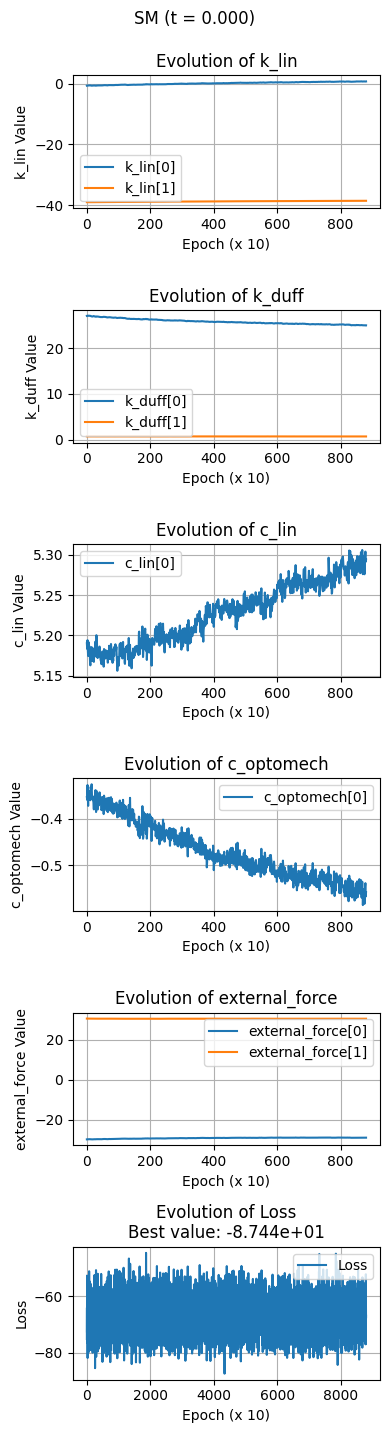

Optimization for time 0.0004941713361323828
Epoch 0 - Loss: -68.8289
Epoch 100 - Loss: -64.6321
Epoch 200 - Loss: -68.2870
Epoch 300 - Loss: -66.7659
Epoch 400 - Loss: -69.2574
Epoch 500 - Loss: -65.7044
Epoch 600 - Loss: -71.0160
Epoch 700 - Loss: -68.5020
Epoch 800 - Loss: -53.8955
Epoch 900 - Loss: -65.5175
Epoch 1000 - Loss: -66.7853
Epoch 1100 - Loss: -66.3057
Epoch 1200 - Loss: -73.8473
Epoch 1300 - Loss: -75.4154
Epoch 1400 - Loss: -57.5882
Epoch 1500 - Loss: -61.3481
Epoch 1600 - Loss: -67.3928
Epoch 1700 - Loss: -72.1713
Epoch 1800 - Loss: -68.3902
Epoch 1900 - Loss: -59.8524
Epoch 2000 - Loss: -55.6423
Epoch 2100 - Loss: -62.6872
Epoch 2200 - Loss: -59.7294
Epoch 2300 - Loss: -57.3889
Epoch 2400 - Loss: -64.5943
Epoch 2500 - Loss: -64.6265
Epoch 2600 - Loss: -72.8641
Epoch 2700 - Loss: -68.2000
Epoch 2800 - Loss: -59.6626
Epoch 2900 - Loss: -62.5218
Epoch 3000 - Loss: -63.2032
Epoch 3100 - Loss: -60.4646
Epoch 3200 - Loss: -61.5058
Epoch 3300 - Loss: -65.6339
Epoch 3400 - Los

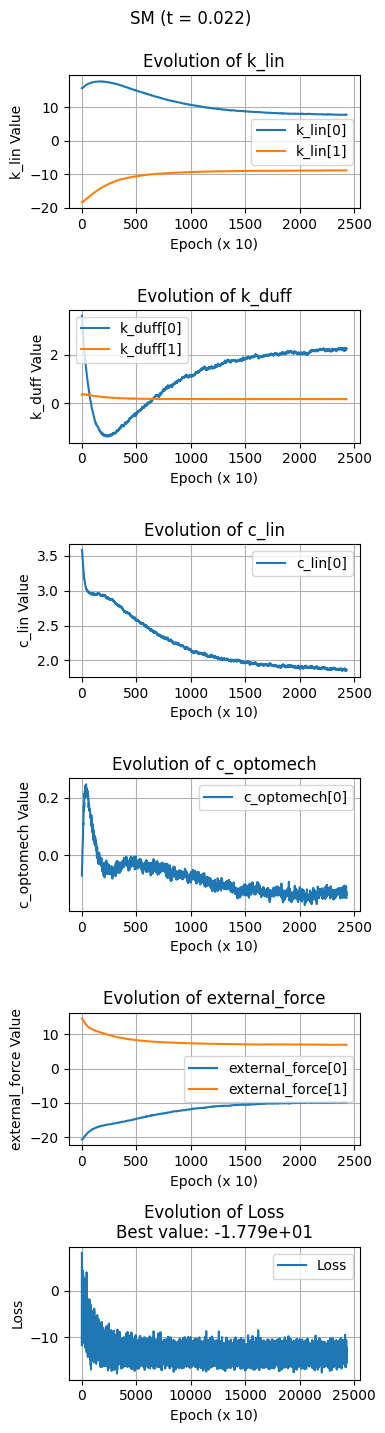

Optimization for time 0.03393221771895324
Epoch 0 - Loss: 4.4417
Epoch 100 - Loss: -9.4216
Epoch 200 - Loss: -7.1033
Epoch 300 - Loss: -10.5475
Epoch 400 - Loss: -8.1599
Epoch 500 - Loss: -7.3007
Epoch 600 - Loss: -6.0267
Epoch 700 - Loss: -7.3845
Epoch 800 - Loss: -9.8540
Epoch 900 - Loss: -9.4888
Epoch 1000 - Loss: -9.6506
Epoch 1100 - Loss: -9.4371
Epoch 1200 - Loss: -9.8385
Epoch 1300 - Loss: -10.0516
Epoch 1400 - Loss: -10.7641
Epoch 1500 - Loss: -7.7599
Epoch 1600 - Loss: -7.0269
Epoch 1700 - Loss: -9.9999
Epoch 1800 - Loss: -10.8216
Epoch 1900 - Loss: -11.4560
Epoch 2000 - Loss: -8.5302
Epoch 2100 - Loss: -8.9319
Epoch 2200 - Loss: -8.2860
Epoch 2300 - Loss: -12.6675
Epoch 2400 - Loss: -9.5161
Epoch 2500 - Loss: -11.0185
Epoch 2600 - Loss: -11.6092
Epoch 2700 - Loss: -8.9075
Epoch 2800 - Loss: -10.5587
Epoch 2900 - Loss: -10.5278
Epoch 3000 - Loss: -9.3593
Epoch 3100 - Loss: -11.6295
Epoch 3200 - Loss: -8.1438
Epoch 3300 - Loss: -10.8826
Epoch 3400 - Loss: -9.7040
Epoch 3500 - L

In [13]:
load_param_histories = False

if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(f"{output_dir}/params_history.npy")
else:
    # Setup optimization parameters
    mask = jnp.ones(params_flattened_initial.shape[0])
    # mask = mask.at[0].set(1.)
    # mask = mask.at[1].set(1.)
    # mask = mask.at[2].set(1.)
    # mask = mask.at[3].set(0.)
    # mask = mask.at[-1].set(1.0)
    # mask = mask.at[-2].set(1.0)

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 10     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = params_flattened_initial

    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print(f"Optimization for time {t_curr}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_curr, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize,
            window_size=window_size,
            tolerance=tolerance,
            patience=patience
        )
        
        _, current_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    time = t_curr,
                    time_index = t_idx,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_curr:.3f})",
                    maximize=maximize,
                    labels_on=True,
                    save_fig=True,
                    path=output_dir,
                    param_names=params_names
                )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)


### Smoothen and interpolate parameter evolution

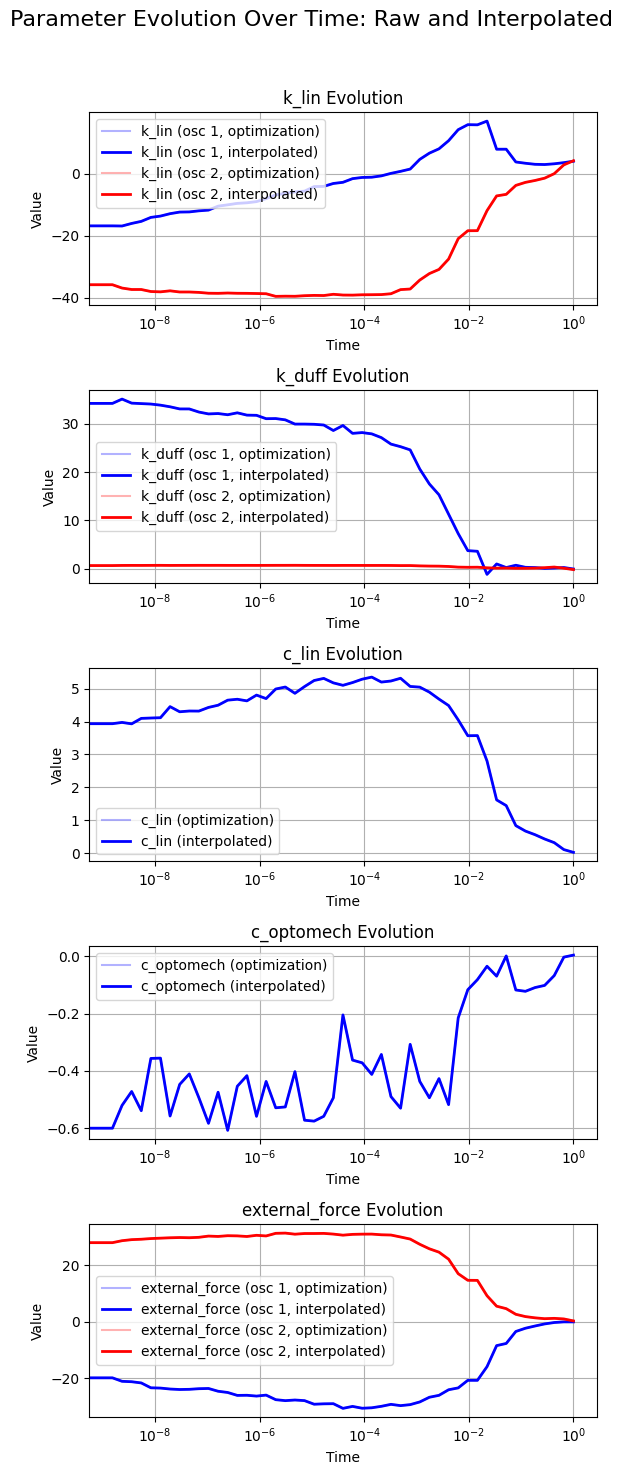

In [14]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t, window_lengths = [10, 10, 10, 10, 10, 10, 10, 10], poly_orders = [3, 3, 3, 3, 3, 3, 3, 3])
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)


plot_parameter_as_fn_of_time(params_names, forward_time_pts,forward_time_pts, params_history_all_t, params_interpolator, unflatten, N_osc) 

# Sampling via reverse SDE

In [15]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:k_lin_0.shape[0]].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1/sigma_forward**2 * forward_params
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

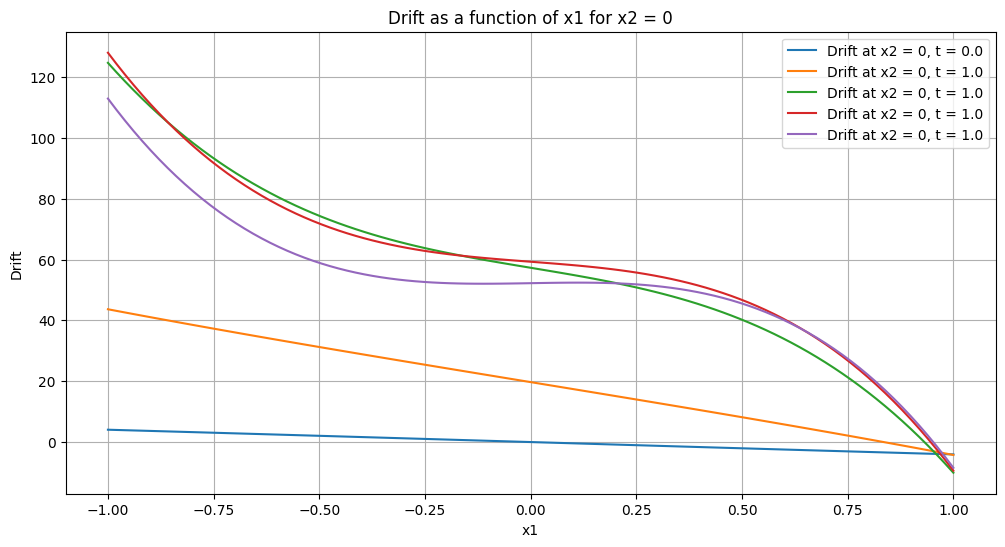

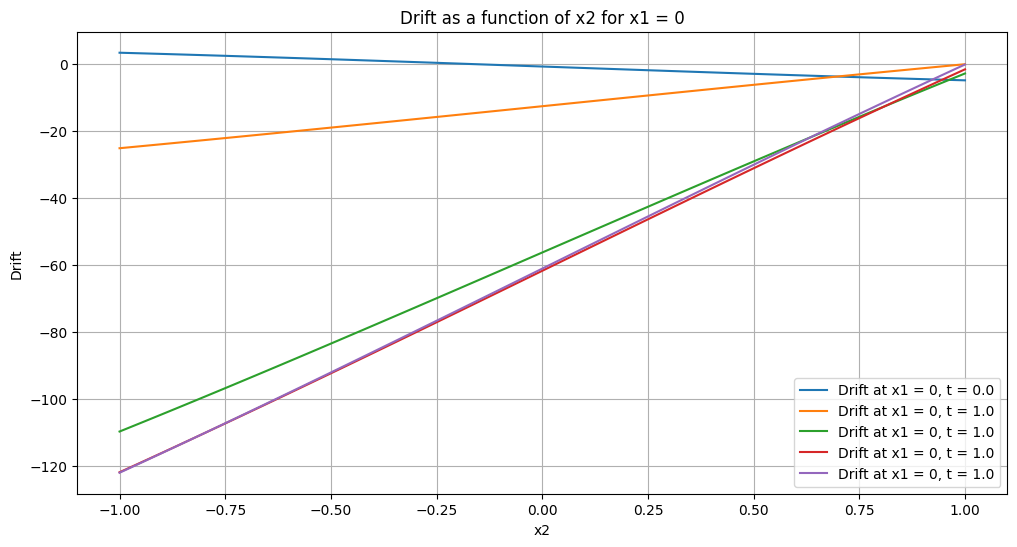

In [16]:
# Define the range for x1 and x2
x_range = jnp.linspace(-1, 1, 100)  # Example range from -5 to 5

# Define filename for saving/loading parameters
n_time_steps = 5
time_steps = t_forward - jnp.exp(jnp.linspace(jnp.log(t_forward), jnp.log(1e-6), n_time_steps))


# Plot drift as a function of x1 for x2 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x1 = [drift_fn(t, jnp.array([x1, 0]), args=())[0] for x1 in x_range]
    plt.plot(x_range, drift_x1, label=f'Drift at x2 = 0, t = {t:.1f}')

plt.xlabel('x1')
plt.ylabel('Drift')
plt.title('Drift as a function of x1 for x2 = 0')
plt.legend()
plt.grid(True)
plt.show()

# Plot drift as a function of x2 for x1 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x2 = [drift_fn(t, jnp.array([0, x2]), args=())[1] for x2 in x_range]
    plt.plot(x_range, drift_x2, label=f'Drift at x1 = 0, t = {t:.1f}')

plt.xlabel('x2')
plt.ylabel('Drift')
plt.title('Drift as a function of x2 for x1 = 0')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 10)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
n_trajectories = 2000
key, subkey = jr.split(key)
initial_states = sample_forward_process(t_forward, n_trajectories, sigma_final=sigma_forward, D=1, samples0=samples_0, key=subkey)
# Sample initial conditions from N(0, I)
# n_trajectories = 1000  # or any other number of trajectories you need
# n_dimensions = 2  # assuming 2D, adjust as necessary
# key, subkey = jr.split(key)
# initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

In [18]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.0,0.])
key_equilibrium = jr.PRNGKey(111111)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,key_equilibrium, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

Solution from reverse process probability distribution total (should be ≈ 1): 1.000000


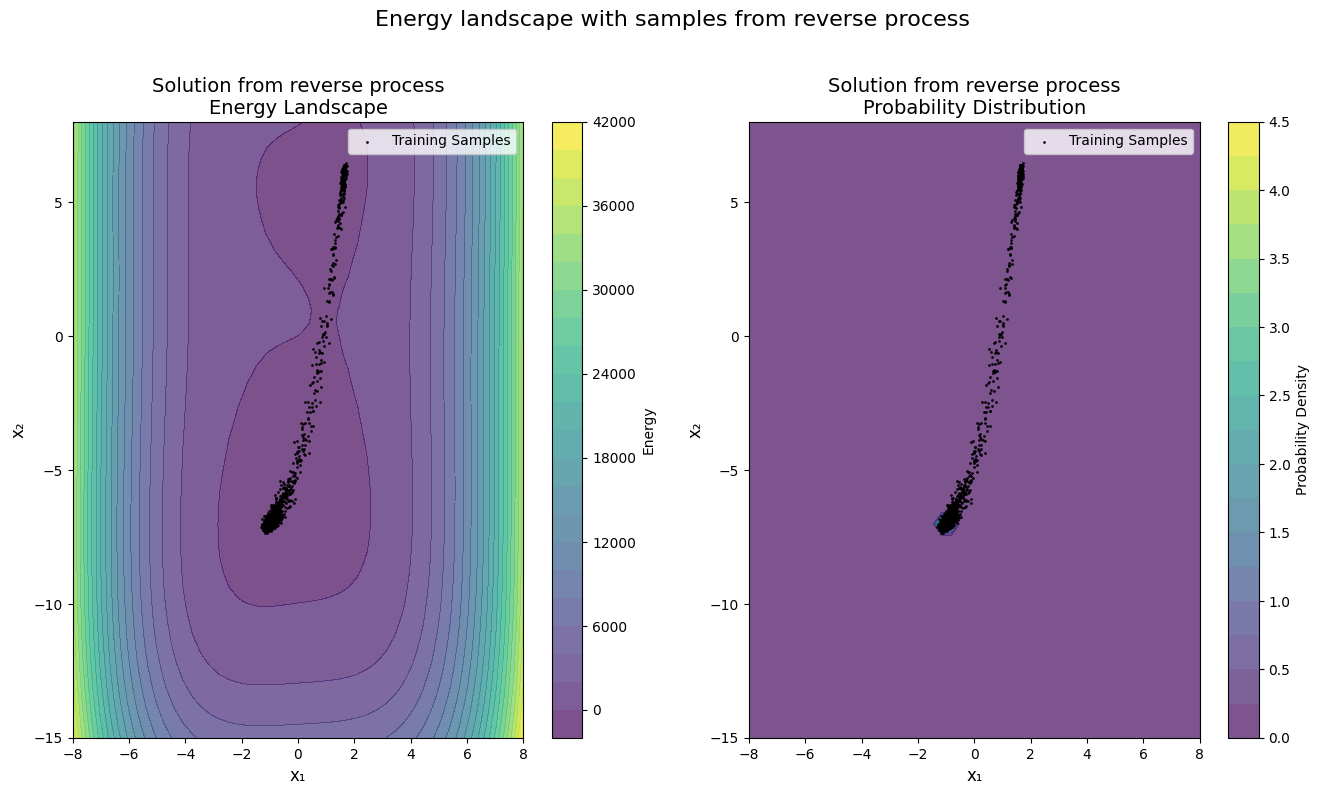

In [19]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-8, 8),    
    x2_range=(-15, 8),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

Solution from direct integration probability distribution total (should be ≈ 1): 1.000000


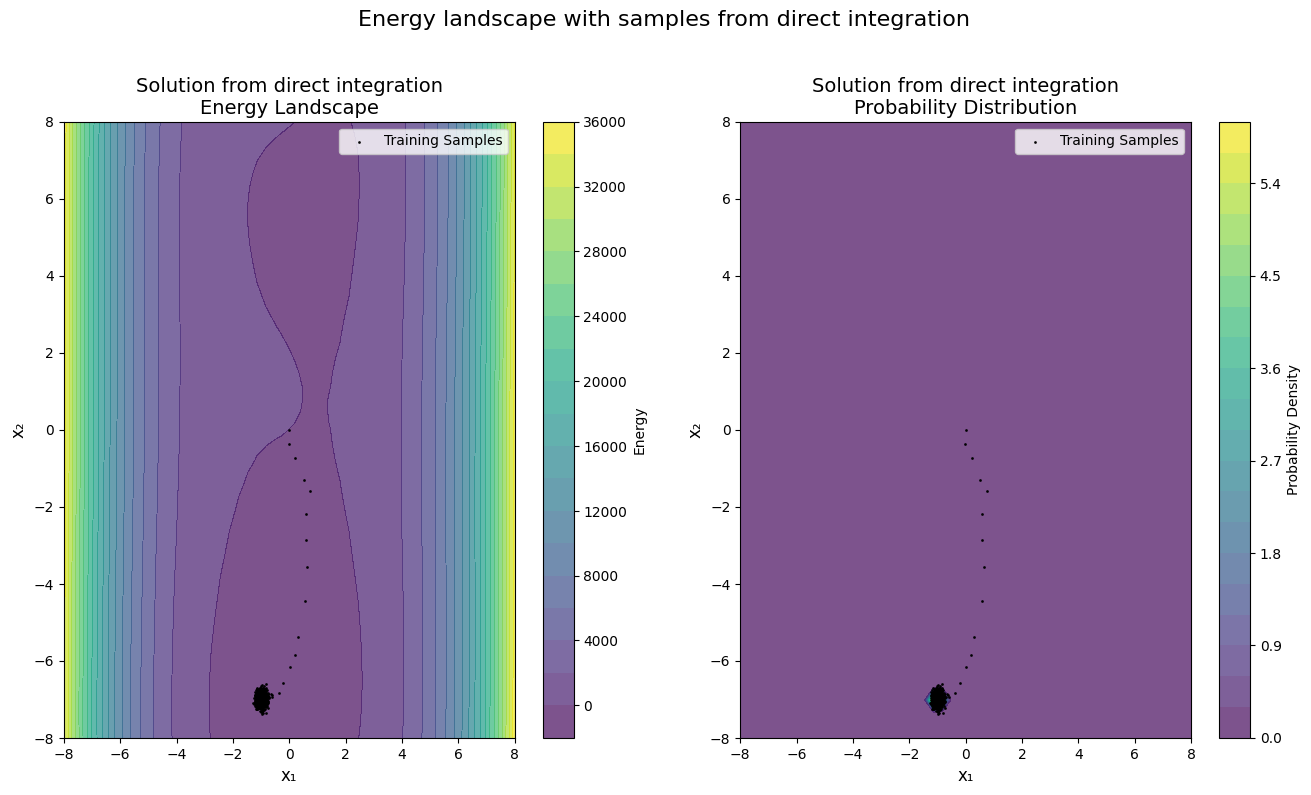

In [20]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=1,
    x1_range=(-8, 8),    
    x2_range=(-8, 8),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

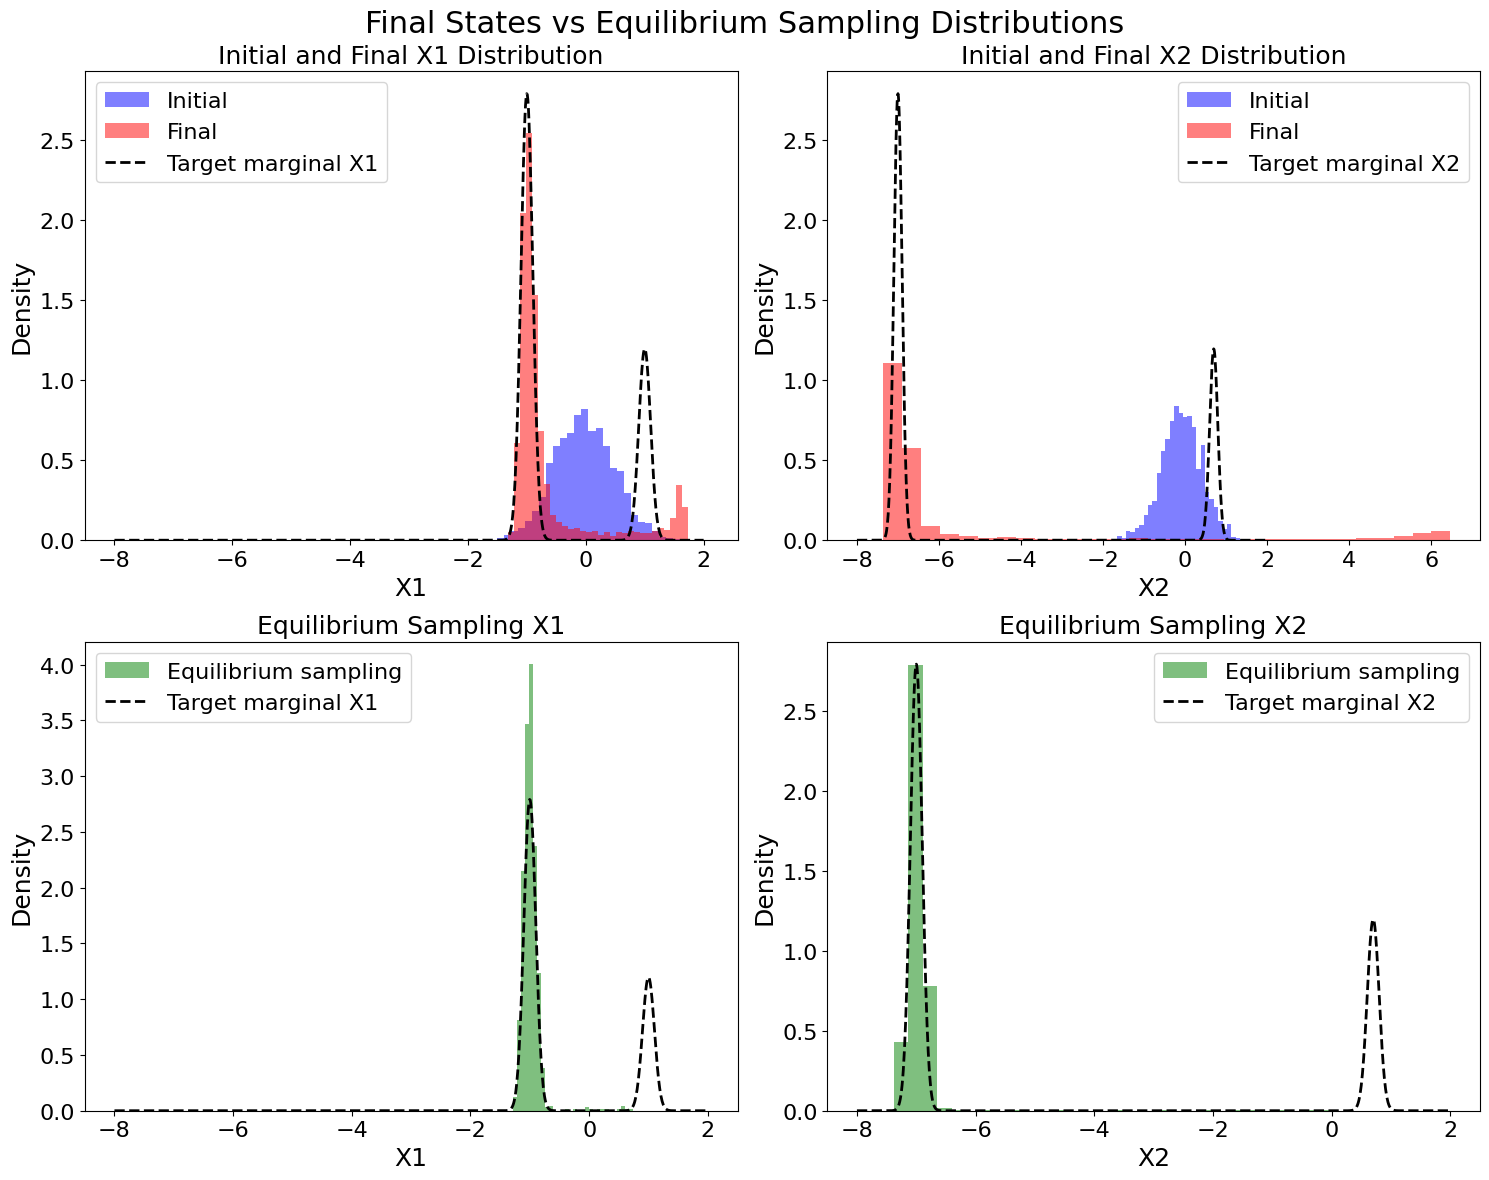

In [21]:
# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-8, 2, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)

ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)

plt.tight_layout()
plt.show()